In [ ]:
!pip -q uninstall -y transformers
!pip -q install -U "transformers==4.44.2" "accelerate>=0.33.0" datasets evaluate sentencepiece rouge_score

import transformers, accelerate
print("transformers:", transformers.__version__)
print("accelerate:", accelerate.__version__)
print("transformers path:", transformers.__file__)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 63.0 MB/s eta 0:00:00
transformers: 4.44.2
accelerate: 1.13.0
transformers path: /usr/local/lib/python3.12/dist-packages/transformers/__init__.py


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

DATA_PATH = "/content/drive/MyDrive/FYP_dataset/finetune1.jsonl"
OUT_DIR   = "/content/drive/MyDrive/FYP_models/test"

# Training config

LIMIT = 3000
MODEL_NAME = "google/mt5-base"
EPOCHS = 3

MAX_INPUT  = 1024
MAX_TARGET = 512

TASK_PREFIX = "සිංහල නීති ලේඛනය සාරාංශ කරන්න: "

In [ ]:
from datasets import load_dataset

ds = load_dataset("json", data_files=DATA_PATH)
full_train = ds["train"]

print("Total rows in file:", len(full_train))
print("Columns:", full_train.column_names)
print("Sample row:", full_train[0])


limit = min(LIMIT, len(full_train))
small_ds = full_train.select(range(limit))
print("Rows used for training:", len(small_ds))


candidates_input  = ["input", "text", "document", "content", "source", "prompt", "article"]
candidates_target = ["summary", "output", "target", "label", "response", "answer"]

cols = small_ds.column_names

def pick_col(cands, cols):
    for c in cands:
        if c in cols:
            return c
    return None

input_col  = pick_col(candidates_input, cols)
target_col = pick_col(candidates_target, cols)

# Fallback: first two columns
if input_col is None or target_col is None:
    if len(cols) >= 2:
        input_col = cols[0]
        target_col = cols[1]
    else:
        raise ValueError("JSONL must have at least two fields: input + summary/target")

print("Detected input column :", input_col)
print("Detected target column:", target_col)

Generating train split: 0 examples [00:00, ? examples/s]

Total rows in file: 3378
Columns: ['id', 'task', 'instruction', 'input', 'output']
Sample row: {'id': '1991-01_S::0001', 'task': 'simplify_summary', 'instruction': 'පහත නීතිමය/රාජ්\u200dය දැනුම්දීමේ පෙළ සරල සිංහලෙන් සාරාංශ කරන්න. එය අදාළ වන්නේ කාටද, මොන ක්\u200dරියාවක්/තීරණයක්/දැනුම්දීමක්ද කියලා පැහැදිලි කරන්න. කාලසීමා හෝ දඩ/දඬුවම් තිබේ නම් සාරාංශයේ සඳහන් කරන්න.', 'input': '1 වැනි කොටස (1) වැනි ඡේදය - සාමාන්\u200dය රජයේ නිවේදන 1)3(., & 877/01, 305. රේගු නිවේදනය සාමාන්\u200dය රේගු ආඥාපනත (235 වැනි පරිච්ඡේදය විනිමය අනුපාතයකි', 'output': 'මෙම නීතිමය/රාජ්\u200dය දැනුම්දීමේ සම්පූර්ණ විස්තරය පහත පරිදි වේ: 1 වැනි කොටස: (1) වැනි ඡේදය - සාමාන්ය රජයේ නිවේදන 1)3(., & 877/01, 305. රේගු නිවේදනය (සාමාන්ය) රේගු ආඥාපනත (235 වැනි පරිච්ඡේදය) විනිමය අනුපාතිකය ඉහත සඳහන් කරුණු සැලකිල්ලට ගනිමින්, නීතිඥයෙකුගේ විස්තරාත්මක සහ පැහැදිලි සාරාංශය පහත පරිදි වේ: මෙම ලේඛනය රජය විසින් නිකුත් කරන ලද රේගු නිවේදනයක් වේ. මෙහි අරමුණ වන්නේ ආනයන හා අපනයන ගනුදෙනු සඳහා භාවිත වන විනිමය අනුපාතය (Exchange Rate) නිල වශයෙන් දැනුම් 

In [ ]:
split1 = small_ds.train_test_split(test_size=0.2, seed=42)

train_ds = split1["train"]
temp_ds  = split1["test"]

split2 = temp_ds.train_test_split(test_size=0.5, seed=42)

eval_ds = split2["train"]   # 10%
test_ds  = split2["test"]    # 10%

print("Train size:", len(train_ds))
print("Valid size:", len(eval_ds))
print("Test size :", len(test_ds))

Train size: 2400
Valid size: 300
Test size : 300


In [ ]:
def clean_text(x):
    if x is None:
        return ""
    return str(x).strip()

# Remove rows with empty input or empty target
train_ds = train_ds.filter(lambda ex: len(clean_text(ex[input_col])) > 0 and len(clean_text(ex[target_col])) > 0)
eval_ds  = eval_ds.filter(lambda ex: len(clean_text(ex[input_col])) > 0 and len(clean_text(ex[target_col])) > 0)
test_ds = test_ds.filter(lambda ex: len(clean_text(ex[input_col])) > 0 and len(clean_text(ex[target_col])) > 0)


print("Clean train size:", len(train_ds))
print("Clean eval size :", len(eval_ds))
print("Clean test size :", len(test_ds))

Filter:   0%|          | 0/2400 [00:00<?, ? examples/s]

Filter:   0%|          | 0/300 [00:00<?, ? examples/s]

Filter:   0%|          | 0/300 [00:00<?, ? examples/s]

Clean train size: 2400
Clean eval size : 300
Clean test size : 300


In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def preprocess(batch):
    inputs  = [TASK_PREFIX + str(x) for x in batch[input_col]]
    targets = [str(x) for x in batch[target_col]]

    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT,
        truncation=True
    )

    labels = tokenizer(
        targets,
        max_length=MAX_TARGET,
        truncation=True
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

train_tok = train_ds.map(preprocess, batched=True, remove_columns=train_ds.column_names)
eval_tok  = eval_ds.map(preprocess, batched=True, remove_columns=eval_ds.column_names)
test_tok  = test_ds.map(preprocess, batched=True, remove_columns=test_ds.column_names)

print("Tokenized sample:", train_tok[0].keys())
print("Train:", len(train_tok), "Valid:", len(eval_tok), "Test:", len(test_tok))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:551: UserWarning: The sentencepiece tokenizer that you are converting

Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Tokenized sample: dict_keys(['input_ids', 'attention_mask', 'labels'])
Train: 2400 Valid: 300 Test: 300


In [ ]:
import numpy as np

ex = train_tok[0]
print("keys:", ex.keys())
print("labels length:", len(ex["labels"]))
print("labels first 30:", ex["labels"][:30])
print("all -100?", all(x == -100 for x in ex["labels"]))
print("all pad?", all(x == tokenizer.pad_token_id for x in ex["labels"]))

keys: dict_keys(['input_ids', 'attention_mask', 'labels'])
labels length: 321
labels first 30: [5834, 1586, 259, 22156, 6114, 42206, 275, 54192, 2670, 24329, 17839, 64233, 1851, 75079, 8242, 68077, 103387, 1674, 2435, 78900, 25189, 12430, 28055, 267, 40183, 260, 16711, 4135, 13643, 2022]
all -100? False
all pad? False


In [ ]:
decoded = tokenizer.decode([x for x in train_tok[0]["labels"] if x != -100], skip_special_tokens=True)
print("Decoded label text:", decoded[:300])

Decoded label text: මෙම නීතිමය/රාජ් ය දැනුම්දීමේ සම්පූර්ණ විස්තරය පහත පරිදි වේ: 157. කැබලි අක්ෂර 'එෆ්එෆ්' -- පරගහකොටුව කුඹුර ~- ප්රමාණය: හෙක. 0.0002 උතුරට: කැබලි අක්ෂර එෆ්ජ් සහ එෆ්ඊ; නැගෙනහිරට: ඊ. ඩබ්ලිව්. එම්. එම්. බී. ඒකනායක හිමිකම් කියන කොළපැලැල්ල කන්ද වත්ත; දකුණට: එල්. ටී. එම්. සී. බී. ගුණතිලක හිමිකම් කියන කොළපැලැල


In [ ]:
from transformers import (
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments
)
import evaluate
import numpy as np
from transformers import EarlyStoppingCallback

# Load model
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

# Data Collator
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

# Metric
rouge = evaluate.load("rouge")

def compute_metrics(eval_pred):
    preds, labels = eval_pred

    if isinstance(preds, tuple):
        preds = preds[0]

    preds = np.array(preds)
    labels = np.array(labels)
    preds = np.clip(preds, 0, tokenizer.vocab_size - 1).astype(np.int64)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id).astype(np.int64)

    # Token level accuracy
    mask = labels != tokenizer.pad_token_id

    # Align preds length to labels length
    if preds.shape[1] < labels.shape[1]:
        pad_width = labels.shape[1] - preds.shape[1]
        preds_aligned = np.pad(preds, ((0, 0), (0, pad_width)), constant_values=tokenizer.pad_token_id)
    else:
        preds_aligned = preds[:, :labels.shape[1]]

    correct = (preds_aligned == labels) & mask
    accuracy = correct.sum() / mask.sum() if mask.sum() > 0 else 0.0

    # Decode for ROUGE
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    scores = rouge.compute(predictions=decoded_preds, references=decoded_labels)
    scores = {k: round(v, 4) for k, v in scores.items()}

    # Add scores
    scores["accuracy"] = round(float(accuracy), 4)

    return scores

# Training args
args = Seq2SeqTrainingArguments(
    output_dir=OUT_DIR,
    evaluation_strategy="steps",
    eval_steps=50,
    save_steps=50,
    logging_dir=f"{OUT_DIR}/runs",
    logging_strategy="steps",
    logging_steps=1,
    logging_first_step=True,
    report_to="tensorboard",
    learning_rate=2e-4,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    num_train_epochs=EPOCHS,
    predict_with_generate=True,
    generation_max_length=512,
    generation_num_beams=4,
    fp16=False,
    bf16=False,
    save_total_limit=2,
    save_safetensors=False,

    # Early stopping and save best model
    load_best_model_at_end=True,
    metric_for_best_model="rouge1",
    greater_is_better=True
)

trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=eval_tok,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

trainer.train()

pytorch_model.bin:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Step,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,Accuracy
50,0.723700,0.591572,0.427500,0.337000,0.421800,0.422100,0.018700
100,0.374900,0.350035,0.823600,0.775300,0.820900,0.822500,0.109000
150,0.360300,0.283710,0.865900,0.817700,0.864500,0.865600,0.110200
200,0.381300,0.253897,0.880300,0.834200,0.878700,0.879100,0.122400
250,0.296100,0.238129,0.884600,0.839800,0.882800,0.883500,0.133400
300,0.334000,0.227075,0.883700,0.839200,0.881900,0.882400,0.119800
350,0.335500,0.213347,0.882500,0.838500,0.881200,0.881300,0.115500
400,0.377500,0.209339,0.884300,0.839800,0.882500,0.882900,0.116700


TrainOutput(global_step=400, training_loss=0.6979200183972716, metrics={'train_runtime': 7921.4421, 'train_samples_per_second': 0.909, 'train_steps_per_second': 0.057, 'total_flos': 3991137459978240.0, 'train_loss': 0.6979200183972716, 'epoch': 2.6666666666666665})

In [ ]:
# F1, Precision, Recall, ROUGE, BLEU, BERTScore evaluation metrixs

!pip -q install bert_score sacrebleu matplotlib seaborn

import torch, json, re
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from evaluate import load as load_metric
from collections import Counter


def get_ngrams(tokens, n):
    return Counter([tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)])

def token_level_prf(pred_str, ref_str):
    """Compute token-level Precision, Recall, F1"""
    pred_tokens = pred_str.strip().split()
    ref_tokens  = ref_str.strip().split()
    common = Counter(pred_tokens) & Counter(ref_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0, 0.0, 0.0
    precision = num_same / len(pred_tokens)
    recall    = num_same / len(ref_tokens)
    f1        = 2 * precision * recall / (precision + recall)
    return precision, recall, f1

def bleu_1gram(pred_str, ref_str):
    pred_tokens = pred_str.strip().split()
    ref_tokens  = ref_str.strip().split()
    if not pred_tokens:
        return 0.0
    common = Counter(pred_tokens) & Counter(ref_tokens)
    return sum(common.values()) / len(pred_tokens)


print("Generating predictions on test set")
model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

all_preds, all_refs = [], []

BATCH = 8
for i in range(0, len(test_ds), BATCH):
    batch_texts = [
        TASK_PREFIX + str(test_ds[j][input_col])
        for j in range(i, min(i + BATCH, len(test_ds)))
    ]
    batch_refs = [
        str(test_ds[j][target_col])
        for j in range(i, min(i + BATCH, len(test_ds)))
    ]

    enc = tokenizer(
        batch_texts, return_tensors="pt",
        max_length=MAX_INPUT, truncation=True, padding=True
    ).to(device)

    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=MAX_TARGET,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=3
        )

    decoded = tokenizer.batch_decode(out, skip_special_tokens=True)
    all_preds.extend([p.strip() for p in decoded])
    all_refs.extend([r.strip() for r in batch_refs])

    if (i // BATCH) % 5 == 0:
        print(f"   {min(i+BATCH, len(test_ds))}/{len(test_ds)} done...")

print(f"Generated {len(all_preds)} predictions")


print("\n Computing per-sample metrics...")
precisions, recalls, f1s = [], [], []
for p, r in zip(all_preds, all_refs):
    pr, rc, f1 = token_level_prf(p, r)
    precisions.append(pr)
    recalls.append(rc)
    f1s.append(f1)

# ROUGE score
rouge_metric = load_metric("rouge")
rouge_scores = rouge_metric.compute(predictions=all_preds, references=all_refs)

# BLEU score
sacrebleu = load_metric("sacrebleu")
bleu_score = sacrebleu.compute(
    predictions=all_preds,
    references=[[r] for r in all_refs]
)

# BERTScore score
print("   Computing BERTScore (this takes ~1 min)...")
bertscore = load_metric("bertscore")
bert_results = bertscore.compute(
    predictions=all_preds,
    references=all_refs,
    lang="si",
    model_type="bert-base-multilingual-cased"
)

# print summary table
print("\n" + "="*55)
print("TEST SET EVALUATION RESULTS")
print("="*55)
print(f"  Samples evaluated      : {len(all_preds)}")
print(f"  Token Precision (avg)  : {np.mean(precisions):.4f}")
print(f"  Token Recall    (avg)  : {np.mean(recalls):.4f}")
print(f"  Token F1        (avg)  : {np.mean(f1s):.4f}")
print(f"  ROUGE-1                : {rouge_scores['rouge1']:.4f}")
print(f"  ROUGE-2                : {rouge_scores['rouge2']:.4f}")
print(f"  ROUGE-L                : {rouge_scores['rougeL']:.4f}")
print(f"  BLEU                   : {bleu_score['score']:.2f}")
print(f"  BERTScore Precision    : {np.mean(bert_results['precision']):.4f}")
print(f"  BERTScore Recall       : {np.mean(bert_results['recall']):.4f}")
print(f"  BERTScore F1           : {np.mean(bert_results['f1']):.4f}")
print("="*55)

# save results to JSON
results_dict = {
    "num_samples"        : len(all_preds),
    "token_precision"    : round(float(np.mean(precisions)), 4),
    "token_recall"       : round(float(np.mean(recalls)), 4),
    "token_f1"           : round(float(np.mean(f1s)), 4),
    "rouge1"             : round(rouge_scores["rouge1"], 4),
    "rouge2"             : round(rouge_scores["rouge2"], 4),
    "rougeL"             : round(rouge_scores["rougeL"], 4),
    "bleu"               : round(bleu_score["score"], 2),
    "bertscore_precision": round(float(np.mean(bert_results["precision"])), 4),
    "bertscore_recall"   : round(float(np.mean(bert_results["recall"])), 4),
    "bertscore_f1"       : round(float(np.mean(bert_results["f1"])), 4),
}
with open(f"{OUT_DIR}/test_results.json", "w") as f:
    json.dump(results_dict, f, indent=2)
print(f"\n Results saved to {OUT_DIR}/test_results.json")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.9 MB/s eta 0:00:00
Generating predictions on test set
   8/300 done...
   48/300 done...
   88/300 done...
   128/300 done...
   168/300 done...
   208/300 done...
   248/300 done...
   288/300 done...
Generated 300 predictions

 Computing per-sample metrics...


   Computing BERTScore (this takes ~1 min)...


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]


TEST SET EVALUATION RESULTS
  Samples evaluated      : 300
  Token Precision (avg)  : 0.7045
  Token Recall    (avg)  : 0.5685
  Token F1        (avg)  : 0.6205
  ROUGE-1                : 0.8569
  ROUGE-2                : 0.8028
  ROUGE-L                : 0.8521
  BLEU                   : 46.28
  BERTScore Precision    : 0.8992
  BERTScore Recall       : 0.9045
  BERTScore F1           : 0.9017

 Results saved to /content/drive/MyDrive/FYP_models/test/test_results.json


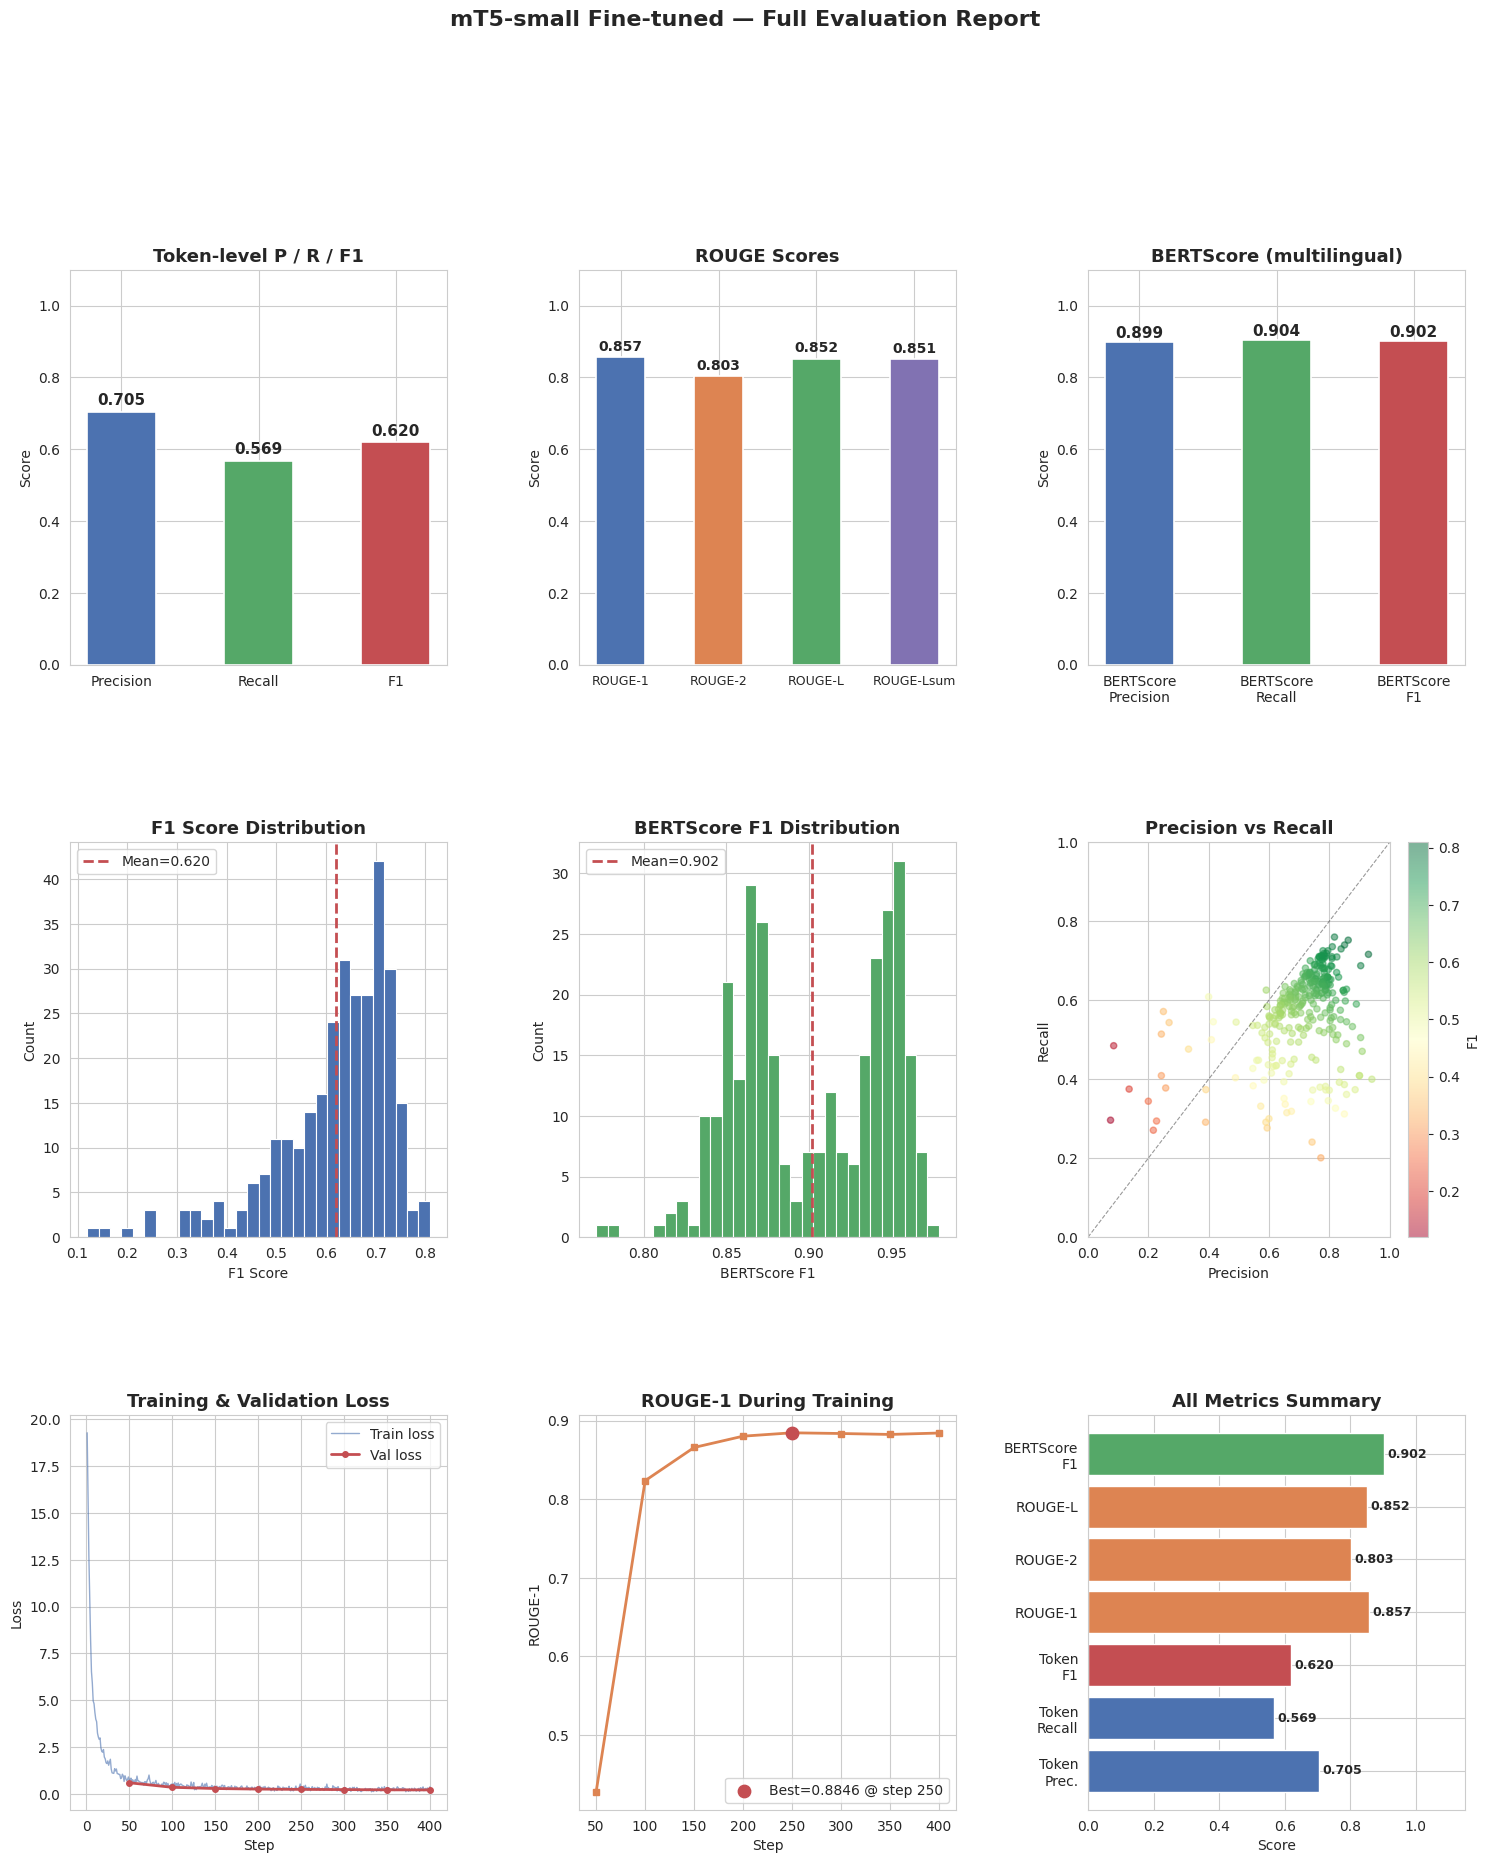

 Figure saved to /content/drive/MyDrive/FYP_models/test/figures/full_evaluation.png


In [ ]:

# Evaluation graphs

sns.set_style("whitegrid")
sns.set_palette("muted")
FIG_DIR = f"{OUT_DIR}/figures"
import os; os.makedirs(FIG_DIR, exist_ok=True)

fig = plt.figure(figsize=(18, 20))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# Precision / Recall / F1 summary graph

ax1 = fig.add_subplot(gs[0, 0])
metrics_names  = ["Precision", "Recall", "F1"]
metrics_values = [np.mean(precisions), np.mean(recalls), np.mean(f1s)]
colors = ["#4C72B0", "#55A868", "#C44E52"]
bars = ax1.bar(metrics_names, metrics_values, color=colors, width=0.5, edgecolor="white", linewidth=1.2)
for bar, val in zip(bars, metrics_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax1.set_ylim(0, 1.1)
ax1.set_title("Token-level P / R / F1", fontsize=13, fontweight="bold")
ax1.set_ylabel("Score")

# ROUGE scores graph
ax2 = fig.add_subplot(gs[0, 1])
rouge_names  = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "ROUGE-Lsum"]
rouge_values = [rouge_scores["rouge1"], rouge_scores["rouge2"],
                rouge_scores["rougeL"], rouge_scores["rougeLsum"]]
bars2 = ax2.bar(rouge_names, rouge_values, color=["#4C72B0","#DD8452","#55A868","#8172B2"],
                width=0.5, edgecolor="white", linewidth=1.2)
for bar, val in zip(bars2, rouge_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.set_ylim(0, 1.1)
ax2.set_title("ROUGE Scores", fontsize=13, fontweight="bold")
ax2.set_ylabel("Score")
ax2.tick_params(axis="x", labelsize=9)

# BERTScore grpah
ax3 = fig.add_subplot(gs[0, 2])
bert_names  = ["BERTScore\nPrecision", "BERTScore\nRecall", "BERTScore\nF1"]
bert_values = [np.mean(bert_results["precision"]),
               np.mean(bert_results["recall"]),
               np.mean(bert_results["f1"])]
bars3 = ax3.bar(bert_names, bert_values, color=["#4C72B0","#55A868","#C44E52"],
                width=0.5, edgecolor="white", linewidth=1.2)
for bar, val in zip(bars3, bert_values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"{val:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax3.set_ylim(0, 1.1)
ax3.set_title("BERTScore (multilingual)", fontsize=13, fontweight="bold")
ax3.set_ylabel("Score")

# F1 per sample grpah
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(f1s, bins=30, color="#4C72B0", edgecolor="white", linewidth=0.8)
ax4.axvline(np.mean(f1s), color="#C44E52", linestyle="--", linewidth=2, label=f"Mean={np.mean(f1s):.3f}")
ax4.set_title("F1 Score Distribution", fontsize=13, fontweight="bold")
ax4.set_xlabel("F1 Score")
ax4.set_ylabel("Count")
ax4.legend()

# BERTScore F1 per sample grpah
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(bert_results["f1"], bins=30, color="#55A868", edgecolor="white", linewidth=0.8)
ax5.axvline(np.mean(bert_results["f1"]), color="#C44E52", linestyle="--", linewidth=2,
            label=f"Mean={np.mean(bert_results['f1']):.3f}")
ax5.set_title("BERTScore F1 Distribution", fontsize=13, fontweight="bold")
ax5.set_xlabel("BERTScore F1")
ax5.set_ylabel("Count")
ax5.legend()

# Precision vs Recall grpah
ax6 = fig.add_subplot(gs[1, 2])
sc = ax6.scatter(precisions, recalls, c=f1s, cmap="RdYlGn", alpha=0.5, s=20)
plt.colorbar(sc, ax=ax6, label="F1")
ax6.plot([0,1],[0,1], "k--", linewidth=0.8, alpha=0.4)
ax6.set_title("Precision vs Recall", fontsize=13, fontweight="bold")
ax6.set_xlabel("Precision")
ax6.set_ylabel("Recall")
ax6.set_xlim(0, 1); ax6.set_ylim(0, 1)

# Training loss curve grpah
ax7 = fig.add_subplot(gs[2, 0])
log_history = trainer.state.log_history
train_steps  = [x["step"] for x in log_history if "loss" in x]
train_losses = [x["loss"] for x in log_history if "loss" in x]
eval_steps   = [x["step"] for x in log_history if "eval_loss" in x]
eval_losses  = [x["eval_loss"] for x in log_history if "eval_loss" in x]
if train_steps:
    ax7.plot(train_steps, train_losses, color="#4C72B0", alpha=0.6, linewidth=1, label="Train loss")
if eval_steps:
    ax7.plot(eval_steps, eval_losses, color="#C44E52", linewidth=2, marker="o", markersize=4, label="Val loss")
ax7.set_title("Training & Validation Loss", fontsize=13, fontweight="bold")
ax7.set_xlabel("Step")
ax7.set_ylabel("Loss")
ax7.legend()

# ROUGE-1 curve during training grpah
ax8 = fig.add_subplot(gs[2, 1])
r1_steps  = [x["step"] for x in log_history if "eval_rouge1" in x]
r1_values = [x["eval_rouge1"] for x in log_history if "eval_rouge1" in x]
if r1_steps:
    ax8.plot(r1_steps, r1_values, color="#DD8452", linewidth=2, marker="s", markersize=4)
    best_idx = np.argmax(r1_values)
    ax8.scatter(r1_steps[best_idx], r1_values[best_idx], color="#C44E52", s=80, zorder=5,
                label=f"Best={r1_values[best_idx]:.4f} @ step {r1_steps[best_idx]}")
ax8.set_title("ROUGE-1 During Training", fontsize=13, fontweight="bold")
ax8.set_xlabel("Step")
ax8.set_ylabel("ROUGE-1")
ax8.legend()

# summary bar grpah
ax9 = fig.add_subplot(gs[2, 2])
all_metric_names = ["Token\nPrec.", "Token\nRecall", "Token\nF1",
                    "ROUGE-1", "ROUGE-2", "ROUGE-L",
                    "BERTScore\nF1"]
all_metric_vals  = [np.mean(precisions), np.mean(recalls), np.mean(f1s),
                    rouge_scores["rouge1"], rouge_scores["rouge2"], rouge_scores["rougeL"],
                    np.mean(bert_results["f1"])]
color_map = ["#4C72B0","#4C72B0","#C44E52","#DD8452","#DD8452","#DD8452","#55A868"]
bars9 = ax9.barh(all_metric_names, all_metric_vals, color=color_map, edgecolor="white", linewidth=1)
for bar, val in zip(bars9, all_metric_vals):
    ax9.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=9, fontweight="bold")
ax9.set_xlim(0, 1.15)
ax9.set_title("All Metrics Summary", fontsize=13, fontweight="bold")
ax9.set_xlabel("Score")

fig.suptitle("mT5-small Fine-tuned — Full Evaluation Report", fontsize=16, fontweight="bold", y=1.01)
plt.savefig(f"{FIG_DIR}/full_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print(f" Figure saved to {FIG_DIR}/full_evaluation.png")

In [ ]:
# show last few logged entries
trainer.state.log_history[-10:]

[{'loss': 0.1658,
  'grad_norm': 0.3936677575111389,
  'learning_rate': 2.5333333333333337e-05,
  'epoch': 2.62,
  'step': 393},
 {'loss': 0.255,
  'grad_norm': 0.4448665976524353,
  'learning_rate': 2.488888888888889e-05,
  'epoch': 2.626666666666667,
  'step': 394},
 {'loss': 0.2917,
  'grad_norm': 0.5492977499961853,
  'learning_rate': 2.4444444444444445e-05,
  'epoch': 2.6333333333333333,
  'step': 395},
 {'loss': 0.184,
  'grad_norm': 0.3588762879371643,
  'learning_rate': 2.4e-05,
  'epoch': 2.64,
  'step': 396},
 {'loss': 0.3114,
  'grad_norm': 0.5232921838760376,
  'learning_rate': 2.3555555555555556e-05,
  'epoch': 2.6466666666666665,
  'step': 397},
 {'loss': 0.2162,
  'grad_norm': 0.4583424925804138,
  'learning_rate': 2.3111111111111112e-05,
  'epoch': 2.6533333333333333,
  'step': 398},
 {'loss': 0.1954,
  'grad_norm': 0.42549216747283936,
  'learning_rate': 2.2666666666666668e-05,
  'epoch': 2.66,
  'step': 399},
 {'loss': 0.3775,
  'grad_norm': 0.6409562826156616,
  'lea

In [ ]:
FINAL_DIR = OUT_DIR + f"/final_limit_{LIMIT}"
trainer.save_model(FINAL_DIR)
tokenizer.save_pretrained(FINAL_DIR)

print("Final model saved to:", FINAL_DIR)

Final model saved to: /content/drive/MyDrive/FYP_models/test/final_limit_3000


In [ ]:
def summarize(text):
    inp = TASK_PREFIX + text
    tok = tokenizer(inp, return_tensors="pt", truncation=True, max_length=MAX_INPUT).to(model.device)
    out = model.generate(**tok, max_new_tokens=300, num_beams=4)
    return tokenizer.decode(out[0], skip_special_tokens=True)

sample = train_ds[0][input_col]
print("INPUT:\n", sample[:500])
print("\nSUMMARY:\n", summarize(sample))

INPUT:
 157. කැබලි අක්ෂර එෆ්එම් -- පිටකොටුව කුඹුර ~- ප්‍ර්‍රමාණය හෙකින් 0.0002 උතුරට කැබලි අක්ෂර එෆ්එම් සහ එෆ් නැගෙනහිරට ඊ ඩබ්ලිව් එම් එම් බී ඒකනායක හිමිකම් කියන කොළ පැලැල්ල කන්ද වත්ත දකුණට එල් ටී එම් සී බී ගුණතිලක හිමිකම් කියන කොළ පැලැල්ල කන්ද වත්ත සහ ඒ සෝම්නාත් නිසා හිමිකම් කියන හුණුකොටුවේ කුඹුර බටහිරට කැබලි අක්ෂර එෆ් එච් සහ එෆ්එම්

SUMMARY:
 මෙම නීතිමය/රාජ් ය දැනුම්දීමේ සම්පූර්ණ විස්තරය පහත පරිදි වේ: 157. කැබලි අක්ෂර එෆ්එම් -- පිටකොටුව කුඹුර ~- ප්රමාණය: හෙක. 0.0002 උතුරට: කැබලි අක්ෂර එෆ්එම් සහ එෆ්; නැගෙනහිරට: ඊ. ඩබ්ලිව්. එම්. එම්. බී. ඒකනායක හිමිකම් කියන කොළපැලැල්ල කන්ද වත්ත; දකුණට: එල්. ටී. එම්. සී. බී. ගුණතිලක හිමිකම් කියන කොළපැලැල්ල කන්ද වත්ත සහ ඒ. සෝම්නාත් නිසා හිමිකම් කියන හුණුකොටුව කුඹුර; බටහිරට: කැබලි අක්ෂර එෆ්එච් සහ එෆ්එම්. ඉහත සඳහන් කරුණු සැලකිල්ලට ගනිමින්, නීතිඥයෙකුගේ විස්තරාත්මක සහ පැහැදිලි සාරාංශය පහත පරිදි වේ: මෙම ලේඛනය රජයේ/නීතිමය දැනුම්දීමක් වේ. මෙහි අරමුණ වන්නේ අදාළ නීතිමය නියමයන් සහ ක් රියා පටිපාටි පැහැදිලි කර දැනුම් දීමයි. මෙවැනි නිවේදන අදාළ ක් රියා පටිපාටි නිවැරදි

In [ ]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
import torch

model_path = "/content/drive/MyDrive/FYP_models/test/final_limit_3000"
model = AutoModelForSeq2SeqLM.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

def summarize(text, max_new_tokens=200):
    inputs = tokenizer(
        text, return_tensors="pt",
        max_length=512, truncation=True
    ).to(device)
    with torch.no_grad():
        output_ids = model.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=max_new_tokens,
            min_length=50,
            num_beams=6,
            early_stopping=False,
            no_repeat_ngram_size=2,
            repetition_penalty=1.2,
            length_penalty=3.0,
            forced_eos_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)


def extract_key_sentences(text, summary, top_n=4):
    """
    Extract the most important sentences from original text
    that are NOT already covered in the model's summary.
    Uses simple word overlap scoring (no extra libraries needed).
    """
    summary_words = set(summary.split())

    import re
    sentences = re.split(r'[.。,，។]', text)
    sentences = [s.strip() for s in sentences if len(s.strip().split()) > 5]

    scored = []
    for sent in sentences:
        words = set(sent.split())
        new_info_score = len(words - summary_words)
        overlap_score  = len(words & summary_words)
        final_score = new_info_score * 0.7 + overlap_score * 0.3
        scored.append((final_score, sent))

    scored.sort(reverse=True)
    return [s for _, s in scored[:top_n]]


def build_long_summary(text):
    print("Step 1: Generating model summary...")
    model_summary = summarize(text, max_new_tokens=200)
    print(f"  Model output: {len(model_summary.split())} words")

    print("Step 2: Extracting additional key sentences...")
    extra_sentences = extract_key_sentences(text, model_summary, top_n=4)

    print("Step 3: Building extended summary...")

    # Combine: model summary + extracted sentences
    extended = model_summary
    for sent in extra_sentences:
        sent_words = set(sent.split())
        existing_words = set(extended.split())
        if len(sent_words - existing_words) > 5:
            extended += " " + sent

    return extended, model_summary


text = """ශ්‍රී ලංකා ප්‍රජාතාන්ත්‍රික සමාජවාදී ජනරජයේ අමාත්‍ය මණ්ඩලයේ අනුමැතියට යටත්ව,
1978 ආණ්ඩුක්‍රම ව්‍යවස්ථාවේ සහ 1920 අංක 20 දරන පනතේ 19 වගන්තිය යටතේ පවරා ඇති
බලතල අනුව, අමාත්‍යවරයා විසින් පහත සඳහන් නියෝගය මෙයින් ප්‍රකාශයට පත් කරනු ලැබේ.
මෙහි අරමුණ වන්නේ, මහජන සුබසාධනය, රාජ්‍ය පරිපාලන කටයුතු නිසි ලෙස ක්‍රියාත්මක
කිරීම, සහ රජයේ සේවා කාර්යක්ෂමතාව වැඩිදියුණු කිරීම සඳහා අදාළ නව නියමයන් හඳුන්වා
දීමයි. ඒ අනුව, 2026 වර්ෂයේ 2023/04/25 දින සිට ක්‍රියාත්මක වන පරිදි, චමිඩු ආයතනය
යටතේ පවත්නා සියලුම නිලධාරීන් සහ අදාළ පාර්ශවයන් විසින් මෙම නියෝගයට අනුකූලව
කටයුතු කළ යුතු බව මෙයින් දැනුම් දෙයි. තවද, මෙම නියෝගය උල්ලංඝනය කරන ඕනෑම
පුද්ගලයෙකු හෝ ආයතනයක් සම්බන්ධයෙන් අදාළ නීතිමය ක්‍රියාමාර්ග ගනු ලබන බවත්,
රජයේ නිල බලධාරීන් විසින් ඒ සඳහා අවශ්‍ය පියවර ගනු ලබන බවත් මෙයින් වැඩිදුරටත්
ප්‍රකාශ කරනු ලැබේ. එබැවින්, මහජනතාව සහ අදාළ සියලු පාර්ශවයන් මෙම ගැසට් නිවේදනය
පිළිබඳ අවධානය යොමු කර, නියමිත පරිදි ක්‍රියා කිරීම අනිවාර්ය වන බව මෙයින් නිල
වශයෙන් ප්‍රකාශයට පත් කරනු ලැබේ."""

extended, base = build_long_summary(text)

print("\n" + "="*60)
print("BASE SUMMARY (model only):")
print("="*60)
print(base)
print(f"\nWord count: {len(base.split())}")

print("\n" + "="*60)
print("EXTENDED SUMMARY (model + extraction):")
print("="*60)
print(extended)
print(f"\nWord count: {len(extended.split())}")

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:551: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Step 1: Generating model summary...
  Model output: 81 words
Step 2: Extracting additional key sentences...
Step 3: Building extended summary...

BASE SUMMARY (model only):
මෙම ගැසට් නිවේදනය පිළිබඳ අවධානය යොමු කර, නියමිත පරිදි ක් රියා කිරීම අනිවාර්ය වන බව මෙයින් නිල වශයෙන් ප්රකාශයට පත් කරනු ලැබේ. ඉහත සඳහන් කරුණු සැලකිල්ලට ගනිමින්, රාජ් ය පරිපාලන කටයුතු නිසි ලෙස ක් රියාත්මක කිරීම, සහ රජයේ සේවා කාර්යක්ෂමතාව වැඩිදියුණු කිරීමසඳහා අදාළ නව නියමයන් හඳුන්වා දීමයි. ඒ අනුව, චමිඩු ආයතනය යටතේ පවත්නා සියලුම නිලධාරීන් සහ පාර්ශවයන් විසින් එම නියෝගයට අනුකූලව ක්රියාත්මක කළ යුතු බවයි. එබැවින්, මහජනතාව සහ අදානළ සීමාවන් මෙහි අරමුණ වන්නේ, ශ්රී ලංකා ප්රජාතාන්ත්රික සමාජවාදී ජනරජයේ අමාත්ය මණ්ඩලයේ අනුමැති

Word count: 81

EXTENDED SUMMARY (model + extraction):
මෙම ගැසට් නිවේදනය පිළිබඳ අවධානය යොමු කර, නියමිත පරිදි ක් රියා කිරීම අනිවාර්ය වන බව මෙයින් නිල වශයෙන් ප්රකාශයට පත් කරනු ලැබේ. ඉහත සඳහන් කරුණු සැලකිල්ලට ගනිමින්, රාජ් ය පරිපාලන කටයුතු නිසි ලෙස ක් රියාත්මක කිරීම, සහ රජයේ සේවා කාර්යක්ෂමතාව වැඩිදියුණු කිරීමසඳ